In [ ]:
!pip install xarray
!pip install xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.2 MB/s eta 0:00:00


In [ ]:
import ee
import xarray as xr
import xee
from xee import helpers
import shapely.geometry
import geemap

In [ ]:
ee.Authenticate()
ee.Initialize(project='ee-marciobcure', opt_url='https://earthengine-highvolume.googleapis.com')

In [ ]:
#map = geemap.Map(basemap = 'SATELLITE')
#map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:
#roi = map.draw_last_feature.geometry()
#roi

In [ ]:
shapely_aoi = shapely.geometry.Polygon([
    [-48.44113, -27.541838],
    [-48.44113, -27.528291],
    [-48.425427, -27.528291],
    [-48.425427, -27.541838],
    [-48.44113, -27.541838]
])

In [ ]:
# Função para mascarar nuvens e aplicar o fator de escala
def mask_and_scale_s2(image):
    qa = image.select('QA60')

    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
           qa.bitwiseAnd(cirrus_bit_mask).eq(0))

    scaled_bands = image.select(['B4', 'B8']).multiply(0.0001)

    return image.addBands(scaled_bands, overwrite=True).updateMask(mask).copyProperties(image, image.propertyNames())


In [ ]:
# Função para calcular o EVI2
def calculate_evi2(image):
  red = image.select('B4')
  nir = image.select('B8')

  evi2 = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 2.4 * RED + 1))',
        {
            'NIR': nir,
            'RED': red
        }).rename('EVI2')
  return image.addBands(evi2)

In [ ]:
# Configuração para xarray.open_dataset com xee
# Definir a projeção e escala desejadas para o download
target_crs = 'EPSG:3857'   # Web Mercator, unidades = metros
scale = 10                 # metros por pixel

print("Preparando para abrir o dataset com xarray e xee...")

# Este bloco de código só será executado se o Earth Engine estiver inicializado.
# No seu ambiente local, após ee.Initialize(), esta parte funcionará.
if ee.data.is_initialized():
    # Definir ee_roi aqui, pois requer a inicialização do Earth Engine
    ee_roi = ee.Geometry.Polygon(
        [[[-48.44113, -27.541838],
[-48.44113, -27.528291],
[-48.425427, -27.528291],
[-48.425427, -27.541838],
[-48.44113, -27.541838]]])

Preparando para abrir o dataset com xarray e xee...


In [ ]:
# Carregar e processar a coleção Sentinel-2
s2_collection = ee.ImageCollection("COPERNICUS/S2_HARMONIZED")\
        .filterDate('2025-12-01', '2026-06-28')\
        .filterBounds(ee_roi)\
        .map(mask_and_scale_s2)\
        .map(calculate_evi2)\
        .select('EVI2')

In [ ]:
count = s2_collection.size().getInfo()
if count == 0:
        print("A coleção de imagens está vazia para a ROI e período especificados.")
        print("Por favor, verifique a ROI e as datas.")
else:
        print(f"Coleção de imagens contém {count} imagens. Abrindo com xarray...")
        try:
            # Usar helpers.fit_geometry para gerar os parâmetros de grade
            grid_params = helpers.fit_geometry(
                geometry=shapely_aoi,
                grid_crs=target_crs,
                grid_scale=(scale, -scale) # xee espera uma tupla (x_scale, y_scale), y_scale é negativo para origem superior esquerda
            )

            ds = xr.open_dataset(
                s2_collection,
                engine='ee',
                **grid_params # Passar os parâmetros de grade usando o operador **
            )
            print("Dataset Xarray criado com sucesso!")
            print(ds)

            # Exemplo de como acessar os dados (isso pode acionar o download)
            # print("Primeira imagem do EVI2:\n", ds['EVI2'].isel(time=0).values)

        except Exception as e:
            print(f"Erro ao abrir o dataset com xarray e xee: {e}")
            print("Verifique se a sua ROI está dentro de uma área com dados Sentinel-2 e se a inicialização do EE está correta.")
        else:
            print("Earth Engine não inicializado. Por favor, descomente e execute ee.Authenticate() e ee.Initialize() no seu ambiente local.")

print("Processo concluído.")


Coleção de imagens contém 99 imagens. Abrindo com xarray...
Dataset Xarray criado com sucesso!
<xarray.Dataset> Size: 12MB
Dimensions:  (time: 99, y: 171, x: 176)
Coordinates:
  * time     (time) datetime64[ns] 792B 2025-12-01T13:19:55.320000 ... 2026-0...
  * y        (y) float64 1kB -3.19e+06 -3.19e+06 ... -3.191e+06 -3.191e+06
  * x        (x) float64 1kB -5.392e+06 -5.392e+06 ... -5.391e+06 -5.391e+06
Data variables:
    EVI2     (time, y, x) float32 12MB ...
Attributes: (12/17)
    date_range:             [1435017600000, 1647993600000]
    description:            <p>Sentinel-2 is a wide-swath, high-resolution, m...
    keywords:               ['copernicus', 'esa', 'eu', 'msi', 'radiance', 's...
    period:                 0
    product_tags:           ['msi', 'radiance']
    provider:               European Union/ESA/Copernicus
    ...                     ...
    title:                  Sentinel-2 MSI: MultiSpectral Instrument, Level-1C
    type_name:              ImageCollection


In [ ]:
monthly = ds.resample(time='ME').mean('time')

monthly

<xarray.Dataset> Size: 846kB
Dimensions:  (time: 7, y: 171, x: 176)
Coordinates:
  * time     (time) datetime64[ns] 56B 2025-12-31 2026-01-31 ... 2026-06-30
  * y        (y) float64 1kB -3.19e+06 -3.19e+06 ... -3.191e+06 -3.191e+06
  * x        (x) float64 1kB -5.392e+06 -5.392e+06 ... -5.391e+06 -5.391e+06
Data variables:
    EVI2     (time, y, x) float32 843kB -0.005336 -0.001397 ... 0.0151 0.0151
Attributes: (12/17)
    date_range:             [1435017600000, 1647993600000]
    description:            <p>Sentinel-2 is a wide-swath, high-resolution, m...
    keywords:               ['copernicus', 'esa', 'eu', 'msi', 'radiance', 's...
    period:                 0
    product_tags:           ['msi', 'radiance']
    provider:               European Union/ESA/Copernicus
    ...                     ...
    title:                  Sentinel-2 MSI: MultiSpectral Instrument, Level-1C
    type_name:              ImageCollection
    visualization_0_bands:  B4,B3,B2
    visualization_0_max:    3000.0
    visualization_0_min:    0.0
    visualization_0_name:   RGB

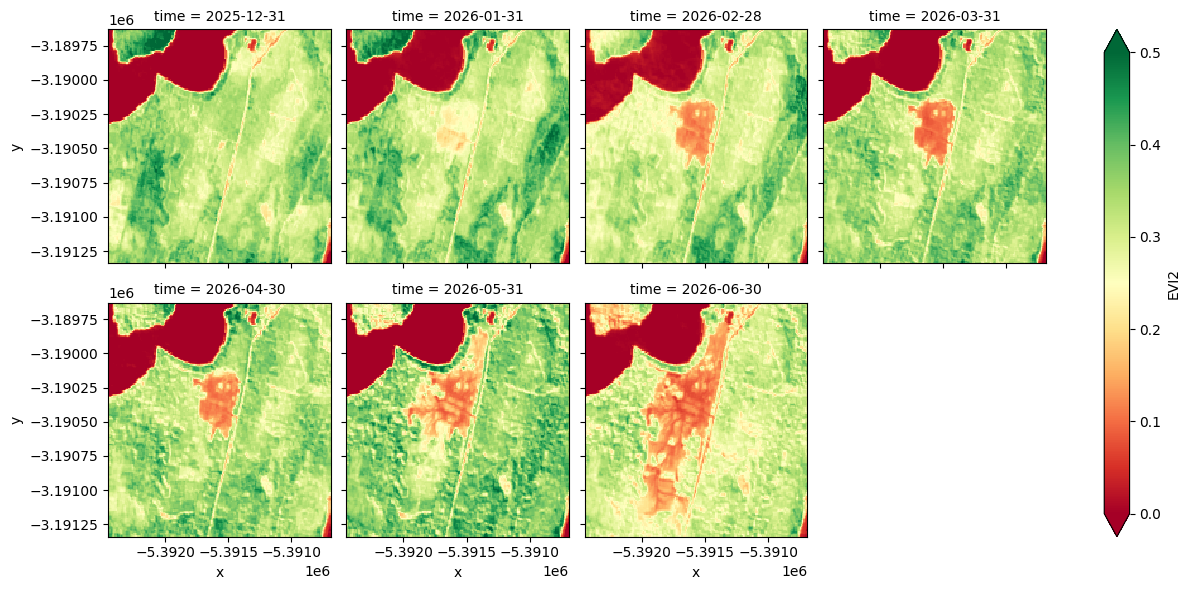

In [ ]:
monthly.EVI2.plot(col = 'time', col_wrap = 4, robust = True, cmap = "RdYlGn", vmin = 0, vmax = 0.5)

In [ ]:
ds.head()

<xarray.Dataset> Size: 620B
Dimensions:  (time: 5, y: 5, x: 5)
Coordinates:
  * time     (time) datetime64[ns] 40B 2025-12-01T13:19:55.320000 ... 2025-12...
  * y        (y) float64 40B -3.19e+06 -3.19e+06 -3.19e+06 -3.19e+06 -3.19e+06
  * x        (x) float64 40B -5.392e+06 -5.392e+06 ... -5.392e+06 -5.392e+06
Data variables:
    EVI2     (time, y, x) float32 500B ...
Attributes: (12/17)
    date_range:             [1435017600000, 1647993600000]
    description:            <p>Sentinel-2 is a wide-swath, high-resolution, m...
    keywords:               ['copernicus', 'esa', 'eu', 'msi', 'radiance', 's...
    period:                 0
    product_tags:           ['msi', 'radiance']
    provider:               European Union/ESA/Copernicus
    ...                     ...
    title:                  Sentinel-2 MSI: MultiSpectral Instrument, Level-1C
    type_name:              ImageCollection
    visualization_0_bands:  B4,B3,B2
    visualization_0_max:    3000.0
    visualization_0_min:    0.0
    visualization_0_name:   RGB

In [ ]:
import matplotlib.pyplot as plt

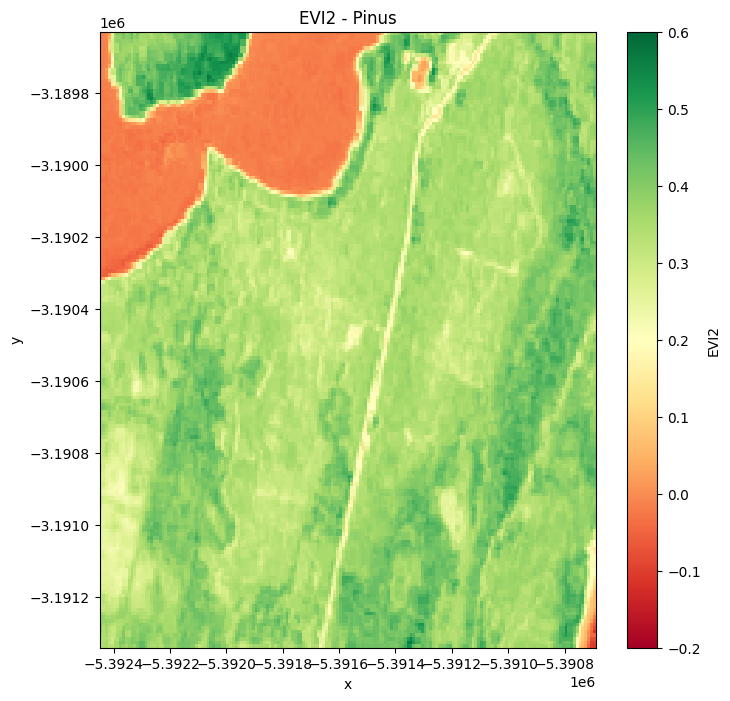

In [ ]:
plt.figure(figsize=(8,8))

ds['EVI2'].isel(time=9).plot(
    cmap='RdYlGn',
    vmin=-.2,
    vmax=.6
)

plt.title("EVI2 - Pinus")
plt.show()

In [ ]:
!pip install plotnine[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 6.6 MB/s eta 0:00:00


In [ ]:
import plotnine as p9

In [ ]:
import pandas as pd

In [ ]:
#df = pd.DataFrame(ds.EVI2.isel(time=11).values.flatten(), columns=['EVI2'])
df = ds.to_dataframe().reset_index()
df.head()


,time,y,x,EVI2
0,2025-12-01 13:19:55.320,-3189635.0,-5392445.0,NaN
1,2025-12-01 13:19:55.320,-3189635.0,-5392435.0,NaN
2,2025-12-01 13:19:55.320,-3189635.0,-5392425.0,NaN
3,2025-12-01 13:19:55.320,-3189635.0,-5392415.0,NaN
4,2025-12-01 13:19:55.320,-3189635.0,-5392405.0,NaN


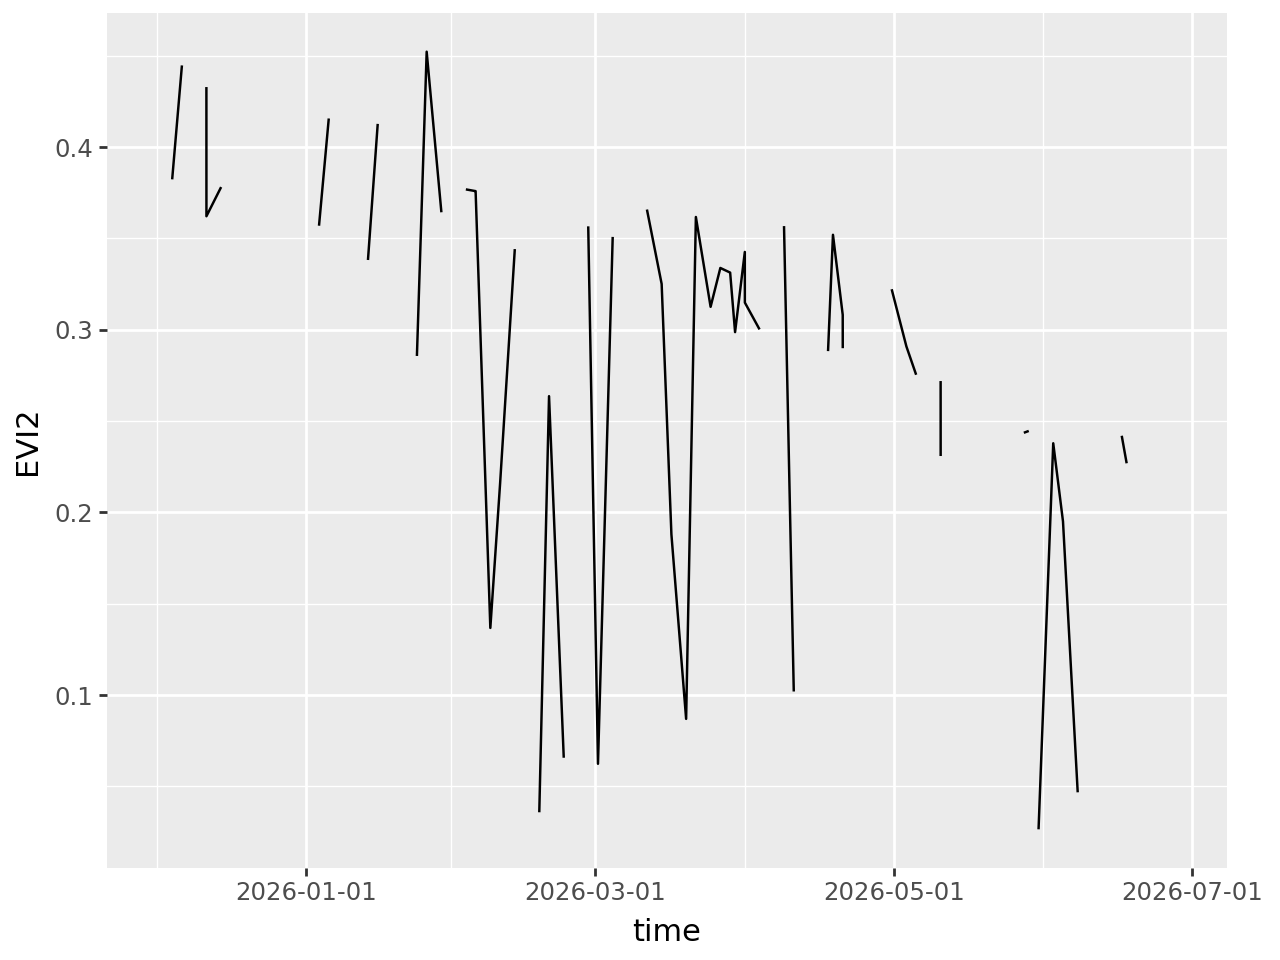

In [ ]:
p9.ggplot(
    df[(df['x'] == -5392245.0) & (df['y'] == -3189635.0)],
    p9.aes(x='time', y = 'EVI2')) + p9.geom_line()